Akurasi: 0.9111

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.82      0.93      0.88        15
   virginica       0.92      0.80      0.86        15

    accuracy                           0.91        45
   macro avg       0.92      0.91      0.91        45
weighted avg       0.92      0.91      0.91        45



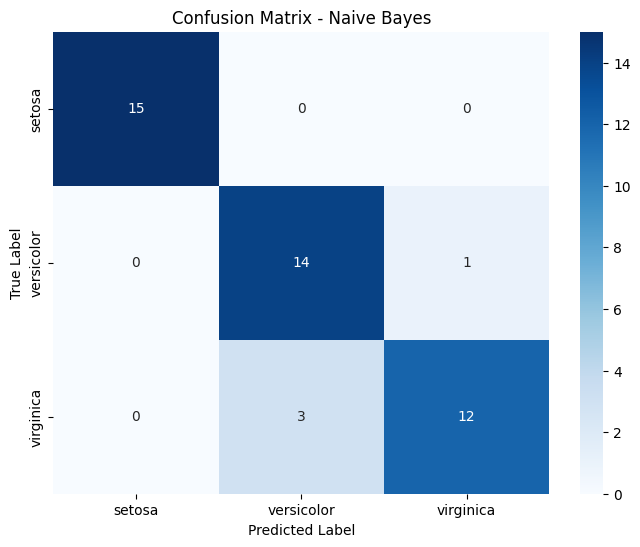


Probabilitas untuk 5 data pertama:
          setosa    versicolor  virginica
0  8.133040e-287  4.099741e-07   1.000000
1  7.203463e-132  9.955071e-01   0.004493
2  6.902840e-164  8.471765e-01   0.152824
3  2.977515e-143  6.679599e-01   0.332040
4  4.843589e-169  1.036414e-01   0.896359


In [ ]:
#IMPLEMENTASI NAIVE BAYES DENGAN SCIKIT-LEARN
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2. Split data
# Membagi data menjadi 70% training dan 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# 3. Gaussian Naive Bayes (untuk data numerik)
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# 4. Prediksi
y_pred = gnb.predict(X_test)

# 5. Evaluasi
print(f"Akurasi: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 6. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 7. Lihat probabilitas posterior
# Melihat peluang masing-masing kelas untuk 5 data pertama di test set
probabilities = gnb.predict_proba(X_test[:5])
print("\nProbabilitas untuk 5 data pertama:")
print(pd.DataFrame(probabilities, columns=iris.target_names))

In [ ]:
#NAIVE BAYES UNTUK KLASIFIKASI TEKS(SPAM FILTER)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
import numpy as np

# Contoh data teks sederhana
emails = [
    "Free money click here win prize",
    "Meeting schedule for tomorrow",
    "Win lottery prize money free",
    "Project deadline extension request",
    "Click link to claim your prize",
    "Quarterly report attachment",
    "Free gift card for you",
    "Team lunch tomorrow"
]

# Label: 1 = spam, 0 = not spam
labels = [1, 0, 1, 0, 1, 0, 1, 0]

# Split manual
X_train = emails[:6]
X_test = emails[6:]
y_train = labels[:6]
y_test = labels[6:]

# Pipeline: Vectorizer + Naive Bayes
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer()),  # atau CountVectorizer()
    ('classifier', MultinomialNB())
])

# Training
pipeline.fit(X_train, y_train)

# Prediksi
y_pred = pipeline.predict(X_test)

print("Data Test:")
for email, pred, actual in zip(X_test, y_pred, y_test):
    status = "SPAM" if pred == 1 else "NOT SPAM"
    print(f"Email: {email}")
    print(f"Prediksi: {status} (Actual: {'SPAM' if actual == 1 else 'NOT SPAM'})")
    print()

# Lihat feature importance (log probabilities)
vectorizer = pipeline.named_steps['vectorizer']
classifier = pipeline.named_steps['classifier']
feature_names = vectorizer.get_feature_names_out()

# Kata dengan probabilitas tertinggi untuk spam
spam_log_prob = classifier.feature_log_prob_[1]
top_spam_idx = np.argsort(spam_log_prob)[-10:]

print("Top 10 kata indikator SPAM:")
for idx in top_spam_idx:
    print(f"{feature_names[idx]}: {np.exp(spam_log_prob[idx]):.4f}")

Data Test:
Email: Free gift card for you
Prediksi: SPAM (Actual: SPAM)

Email: Team lunch tomorrow
Prediksi: NOT SPAM (Actual: NOT SPAM)

Top 10 kata indikator SPAM:
to: 0.0495
claim: 0.0495
your: 0.0495
here: 0.0512
lottery: 0.0528
click: 0.0606
free: 0.0633
money: 0.0633
win: 0.0633
prize: 0.0693


In [ ]:
#IMPLEMENTASI K-NN DENGAN SCIKIT-LEARN
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score
import numpy as np

# Load dataset
wine = load_wine()
X = wine.data
y = wine.target

# Normalisasi SANGAT PENTING untuk k-NN!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

# k-NN dengan k=5
knn = KNeighborsClassifier(n_neighbors=5, weights='uniform')
knn.fit(X_train, y_train)

# Prediksi
y_pred = knn.predict(X_test)
print(f"Akurasi (k=5): {accuracy_score(y_test, y_pred):.4f}")

# Tuning parameter k dengan cross-validation
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"\nParameter terbaik: {grid_search.best_params_}")
print(f"Akurasi CV terbaik: {grid_search.best_score_:.4f}")

# Evaluasi model terbaik
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test)

print(f"Akurasi test set: {accuracy_score(y_test, y_pred_best):.4f}")

Akurasi (k=5): 0.9444

Parameter terbaik: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'uniform'}
Akurasi CV terbaik: 0.9753
Akurasi test set: 0.9815


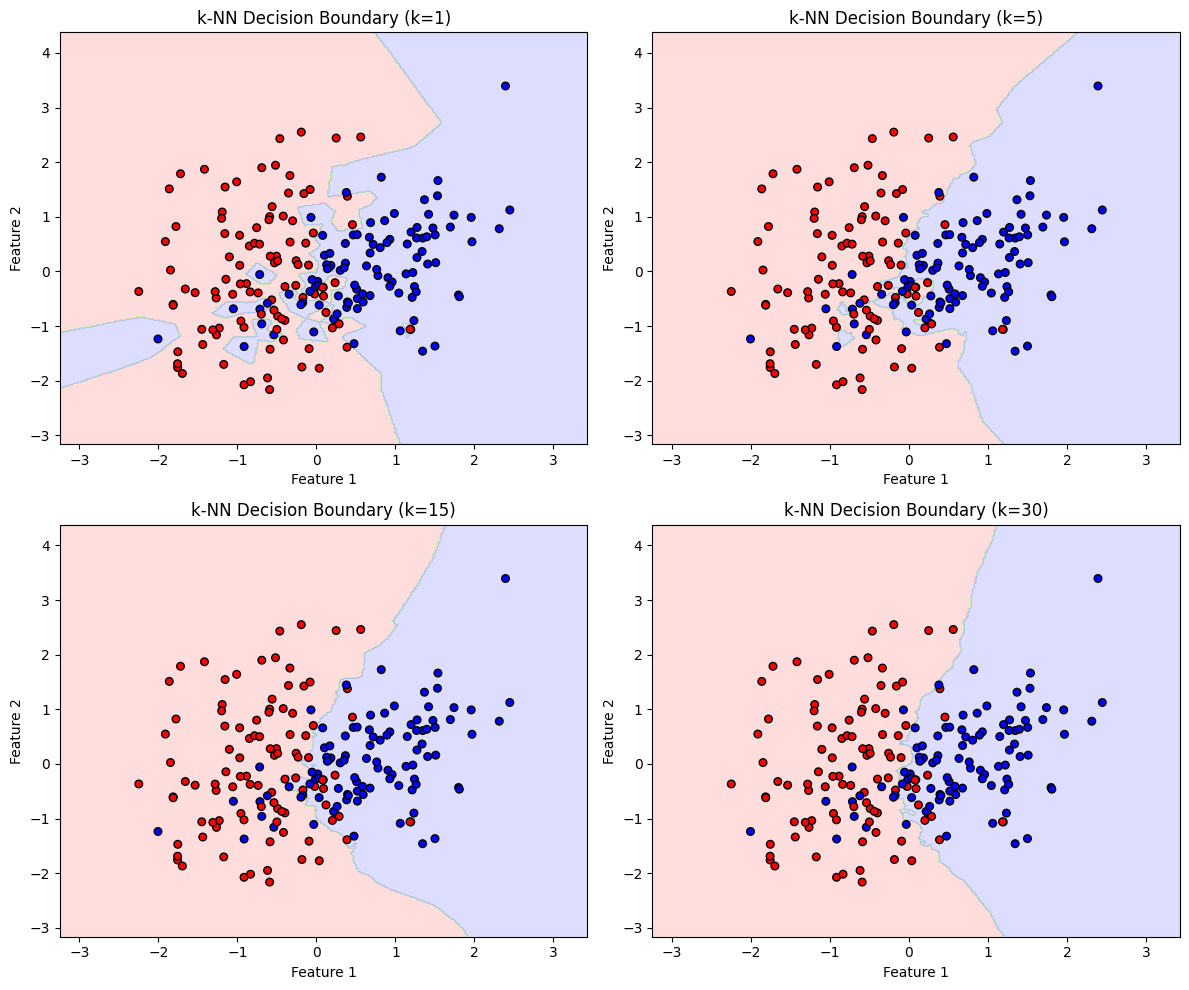

In [ ]:
#VISUALISASI DECISION BOUNDARY K-NN
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler # Tambahan agar tidak error
from matplotlib.colors import ListedColormap

# 1. Generate dataset 2D untuk visualisasi
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

# 2. Normalisasi
X = StandardScaler().fit_transform(X)

# 3. Buat model untuk berbagai nilai k
k_values = [1, 5, 15, 30]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

# Warna untuk plot
cmap_background = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_points = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

# 4. Loop untuk melakukan fitting dan plotting berdasarkan nilai k
for idx, k in enumerate(k_values):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X, y)

    # Plot decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, 0.02),
        np.arange(y_min, y_max, 0.02)
    )

    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Menggambar background warna
    axes[idx].contourf(xx, yy, Z, alpha=0.4, cmap=cmap_background)

    # Menggambar titik data (scatter plot)
    axes[idx].scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_points, edgecolor='black', s=30)

    axes[idx].set_title(f'k-NN Decision Boundary (k={k})')
    axes[idx].set_xlabel('Feature 1')
    axes[idx].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

# Observasi (berdasarkan catatan di gambar):
# - k=1:  boundary sangat kompleks (overfitting)
# - k=5:  boundary lebih halus
# - k=15: semakin smooth
# - k=30: terlalu smooth (underfitting)

In [ ]:
#PERBANDINGAN PERFORMA NAIVE BAYES VS K-NN
import pandas as pd
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.model_selection import cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# 1. Generate berbagai jenis dataset
datasets = {
    'Linear': make_classification(n_samples=500, n_features=10, n_informative=8, random_state=42),
    'Moons': make_moons(n_samples=500, noise=0.1, random_state=42),
    'Circles': make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=42)
}

# 2. Model yang akan dibandingkan
models = {
    'Naive Bayes': GaussianNB(),
    'k-NN (k=3)': KNeighborsClassifier(n_neighbors=3),
    'k-NN (k=7)': KNeighborsClassifier(n_neighbors=7),
    'k-NN (k=15)': KNeighborsClassifier(n_neighbors=15)
}

# 3. Bandingkan performa
results = []

for dataset_name, (X, y) in datasets.items():
    # Normalisasi untuk k-NN
    X_scaled = StandardScaler().fit_transform(X)

    for model_name, model in models.items():
        # Logika pemilihan data: k-NN butuh scaling, NB tidak wajib untuk data ini
        if 'k-NN' in model_name:
            X_use = X_scaled
        else:
            X_use = X

        # Cross-validation
        scores = cross_val_score(model, X_use, y, cv=5, scoring='accuracy')

        results.append({
            'Dataset': dataset_name,
            'Model': model_name,
            'Mean Accuracy': scores.mean(),
            'Std': scores.std()
        })

# 4. Tampilkan hasil dalam DataFrame
results_df = pd.DataFrame(results)
print("Hasil Performa Lengkap:")
print(results_df.round(4))

# 5. Pivot table untuk perbandingan yang lebih mudah dibaca
pivot = results_df.pivot(index='Dataset', columns='Model', values='Mean Accuracy')
print("\nPerbandingan Akurasi Rata-rata (Pivot):")
print(pivot.round(4))

Hasil Performa Lengkap:
    Dataset        Model  Mean Accuracy     Std
0    Linear  Naive Bayes          0.730  0.0316
1    Linear   k-NN (k=3)          0.894  0.0242
2    Linear   k-NN (k=7)          0.886  0.0102
3    Linear  k-NN (k=15)          0.880  0.0352
4     Moons  Naive Bayes          0.870  0.0443
5     Moons   k-NN (k=3)          1.000  0.0000
6     Moons   k-NN (k=7)          1.000  0.0000
7     Moons  k-NN (k=15)          1.000  0.0000
8   Circles  Naive Bayes          1.000  0.0000
9   Circles   k-NN (k=3)          1.000  0.0000
10  Circles   k-NN (k=7)          1.000  0.0000
11  Circles  k-NN (k=15)          1.000  0.0000

Perbandingan Akurasi Rata-rata (Pivot):
Model    Naive Bayes  k-NN (k=15)  k-NN (k=3)  k-NN (k=7)
Dataset                                                  
Circles         1.00         1.00       1.000       1.000
Linear          0.73         0.88       0.894       0.886
Moons           0.87         1.00       1.000       1.000
